# 🍽️ Task 2 - Restaurant Recommendation System

### Objective
Build a restaurant recommendation system based on user preferences using a content-based filtering approach.

### Recommendation Criteria
The system will consider restaurant characteristics such as:

- Cuisine preference
- Price range
- City/location
- Aggregate rating
- Restaurant features/services

### Approach
Content-Based Filtering

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv("Dataset.csv")

print("Dataset Shape:", df.shape)
df.head()

Dataset Shape: (9551, 21)


,Restaurant ID,Restaurant Name,Country Code,City,Address,Locality,Locality Verbose,Longitude,Latitude,Cuisines,...,Currency,Has Table booking,Has Online delivery,Is delivering now,Switch to order menu,Price range,Aggregate rating,Rating color,Rating text,Votes
0,6317637,Le Petit Souffle,162,Makati City,"Third Floor, Century City Mall, Kalayaan Avenu...","Century City Mall, Poblacion, Makati City","Century City Mall, Poblacion, Makati City, Mak...",121.027535,14.565443,"French, Japanese, Desserts",...,Botswana Pula(P),Yes,No,No,No,3,4.8,Dark Green,Excellent,314
1,6304287,Izakaya Kikufuji,162,Makati City,"Little Tokyo, 2277 Chino Roces Avenue, Legaspi...","Little Tokyo, Legaspi Village, Makati City","Little Tokyo, Legaspi Village, Makati City, Ma...",121.014101,14.553708,Japanese,...,Botswana Pula(P),Yes,No,No,No,3,4.5,Dark Green,Excellent,591
2,6300002,Heat - Edsa Shangri-La,162,Mandaluyong City,"Edsa Shangri-La, 1 Garden Way, Ortigas, Mandal...","Edsa Shangri-La, Ortigas, Mandaluyong City","Edsa Shangri-La, Ortigas, Mandaluyong City, Ma...",121.056831,14.581404,"Seafood, Asian, Filipino, Indian",...,Botswana Pula(P),Yes,No,No,No,4,4.4,Green,Very Good,270
3,6318506,Ooma,162,Mandaluyong City,"Third Floor, Mega Fashion Hall, SM Megamall, O...","SM Megamall, Ortigas, Mandaluyong City","SM Megamall, Ortigas, Mandaluyong City, Mandal...",121.056475,14.585318,"Japanese, Sushi",...,Botswana Pula(P),No,No,No,No,4,4.9,Dark Green,Excellent,365
4,6314302,Sambo Kojin,162,Mandaluyong City,"Third Floor, Mega Atrium, SM Megamall, Ortigas...","SM Megamall, Ortigas, Mandaluyong City","SM Megamall, Ortigas, Mandaluyong City, Mandal...",121.057508,14.584450,"Japanese, Korean",...,Botswana Pula(P),Yes,No,No,No,4,4.8,Dark Green,Excellent,229


In [2]:
# Basic Information

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9551 entries, 0 to 9550
Data columns (total 21 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Restaurant ID         9551 non-null   int64  
 1   Restaurant Name       9551 non-null   object 
 2   Country Code          9551 non-null   int64  
 3   City                  9551 non-null   object 
 4   Address               9551 non-null   object 
 5   Locality              9551 non-null   object 
 6   Locality Verbose      9551 non-null   object 
 7   Longitude             9551 non-null   float64
 8   Latitude              9551 non-null   float64
 9   Cuisines              9542 non-null   object 
 10  Average Cost for two  9551 non-null   int64  
 11  Currency              9551 non-null   object 
 12  Has Table booking     9551 non-null   object 
 13  Has Online delivery   9551 non-null   object 
 14  Is delivering now     9551 non-null   object 
 15  Switch to order menu 

In [3]:
# Missing Values

df.isnull().sum()

Restaurant ID           0
Restaurant Name         0
Country Code            0
City                    0
Address                 0
Locality                0
Locality Verbose        0
Longitude               0
Latitude                0
Cuisines                9
Average Cost for two    0
Currency                0
Has Table booking       0
Has Online delivery     0
Is delivering now       0
Switch to order menu    0
Price range             0
Aggregate rating        0
Rating color            0
Rating text             0
Votes                   0
dtype: int64

In [4]:
# Duplicate Records

print("Duplicate Rows :", df.duplicated().sum())

Duplicate Rows : 0


In [5]:
# Dataset Overview

df.describe(include="all")

,Restaurant ID,Restaurant Name,Country Code,City,Address,Locality,Locality Verbose,Longitude,Latitude,Cuisines,...,Currency,Has Table booking,Has Online delivery,Is delivering now,Switch to order menu,Price range,Aggregate rating,Rating color,Rating text,Votes
count,9.551000e+03,9551,9551.000000,9551,9551,9551,9551,9551.000000,9551.000000,9542,...,9551,9551,9551,9551,9551,9551.000000,9551.000000,9551,9551,9551.000000
unique,NaN,7446,NaN,141,8918,1208,1265,NaN,NaN,1825,...,12,2,2,2,1,NaN,NaN,6,6,NaN
top,NaN,Cafe Coffee Day,NaN,New Delhi,"Sector 41, Noida",Connaught Place,"Connaught Place, New Delhi",NaN,NaN,North Indian,...,Indian Rupees(Rs.),No,No,No,No,NaN,NaN,Orange,Average,NaN
freq,NaN,83,NaN,5473,11,122,122,NaN,NaN,936,...,8652,8393,7100,9517,9551,NaN,NaN,3737,3737,NaN
mean,9.051128e+06,NaN,18.365616,NaN,NaN,NaN,NaN,64.126574,25.854381,NaN,...,NaN,NaN,NaN,NaN,NaN,1.804837,2.666370,NaN,NaN,156.909748
std,8.791521e+06,NaN,56.750546,NaN,NaN,NaN,NaN,41.467058,11.007935,NaN,...,NaN,NaN,NaN,NaN,NaN,0.905609,1.516378,NaN,NaN,430.169145
min,5.300000e+01,NaN,1.000000,NaN,NaN,NaN,NaN,-157.948486,-41.330428,NaN,...,NaN,NaN,NaN,NaN,NaN,1.000000,0.000000,NaN,NaN,0.000000
25%,3.019625e+05,NaN,1.000000,NaN,NaN,NaN,NaN,77.081343,28.478713,NaN,...,NaN,NaN,NaN,NaN,NaN,1.000000,2.500000,NaN,NaN,5.000000
50%,6.004089e+06,NaN,1.000000,NaN,NaN,NaN,NaN,77.191964,28.570469,NaN,...,NaN,NaN,NaN,NaN,NaN,2.000000,3.200000,NaN,NaN,31.000000
75%,1.835229e+07,NaN,1.000000,NaN,NaN,NaN,NaN,77.282006,28.642758,NaN,...,NaN,NaN,NaN,NaN,NaN,2.000000,3.700000,NaN,NaN,131.000000


In [6]:
# Column Names

df.columns

Index(['Restaurant ID', 'Restaurant Name', 'Country Code', 'City', 'Address',
       'Locality', 'Locality Verbose', 'Longitude', 'Latitude', 'Cuisines',
       'Average Cost for two', 'Currency', 'Has Table booking',
       'Has Online delivery', 'Is delivering now', 'Switch to order menu',
       'Price range', 'Aggregate rating', 'Rating color', 'Rating text',
       'Votes'],
      dtype='object')

## 📊 Dataset Overview

The dataset contains information about restaurants including:

- Restaurant Name
- City
- Cuisines
- Average Cost for Two
- Price Range
- Aggregate Rating
- Online Delivery
- Table Booking
- Votes

These attributes will be used to build a content-based restaurant recommendation system.

In [7]:
recommend_df = df[
    [
        "Restaurant Name",
        "City",
        "Cuisines",
        "Average Cost for two",
        "Price range",
        "Aggregate rating",
        "Has Online delivery",
        "Has Table booking",
        "Votes"
    ]
].copy()

recommend_df.head()

,Restaurant Name,City,Cuisines,Average Cost for two,Price range,Aggregate rating,Has Online delivery,Has Table booking,Votes
0,Le Petit Souffle,Makati City,"French, Japanese, Desserts",1100,3,4.8,No,Yes,314
1,Izakaya Kikufuji,Makati City,Japanese,1200,3,4.5,No,Yes,591
2,Heat - Edsa Shangri-La,Mandaluyong City,"Seafood, Asian, Filipino, Indian",4000,4,4.4,No,Yes,270
3,Ooma,Mandaluyong City,"Japanese, Sushi",1500,4,4.9,No,No,365
4,Sambo Kojin,Mandaluyong City,"Japanese, Korean",1500,4,4.8,No,Yes,229


In [8]:
recommend_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9551 entries, 0 to 9550
Data columns (total 9 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Restaurant Name       9551 non-null   object 
 1   City                  9551 non-null   object 
 2   Cuisines              9542 non-null   object 
 3   Average Cost for two  9551 non-null   int64  
 4   Price range           9551 non-null   int64  
 5   Aggregate rating      9551 non-null   float64
 6   Has Online delivery   9551 non-null   object 
 7   Has Table booking     9551 non-null   object 
 8   Votes                 9551 non-null   int64  
dtypes: float64(1), int64(3), object(5)
memory usage: 671.7+ KB


In [9]:
recommend_df.isnull().sum()

Restaurant Name         0
City                    0
Cuisines                9
Average Cost for two    0
Price range             0
Aggregate rating        0
Has Online delivery     0
Has Table booking       0
Votes                   0
dtype: int64

In [10]:

# Remove rows where Cuisines is missing

recommend_df = recommend_df.dropna(subset=["Cuisines"])

print("Dataset Shape:", recommend_df.shape)

Dataset Shape: (9542, 9)


In [11]:
# Remove duplicate restaurants

recommend_df = recommend_df.drop_duplicates()

print("Dataset Shape after removing duplicates:", recommend_df.shape)

Dataset Shape after removing duplicates: (9499, 9)


In [12]:
# Reset index

recommend_df.reset_index(drop=True, inplace=True)

recommend_df.head()

,Restaurant Name,City,Cuisines,Average Cost for two,Price range,Aggregate rating,Has Online delivery,Has Table booking,Votes
0,Le Petit Souffle,Makati City,"French, Japanese, Desserts",1100,3,4.8,No,Yes,314
1,Izakaya Kikufuji,Makati City,Japanese,1200,3,4.5,No,Yes,591
2,Heat - Edsa Shangri-La,Mandaluyong City,"Seafood, Asian, Filipino, Indian",4000,4,4.4,No,Yes,270
3,Ooma,Mandaluyong City,"Japanese, Sushi",1500,4,4.9,No,No,365
4,Sambo Kojin,Mandaluyong City,"Japanese, Korean",1500,4,4.8,No,Yes,229


## Data Cleaning

The following preprocessing steps were performed:

- Removed restaurants with missing cuisine information.
- Removed duplicate records.
- Reset the dataframe index.
- Prepared a clean dataset for building the recommendation engine.

C:\Users\pc\AppData\Local\Temp\ipykernel_7216\1210048864.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


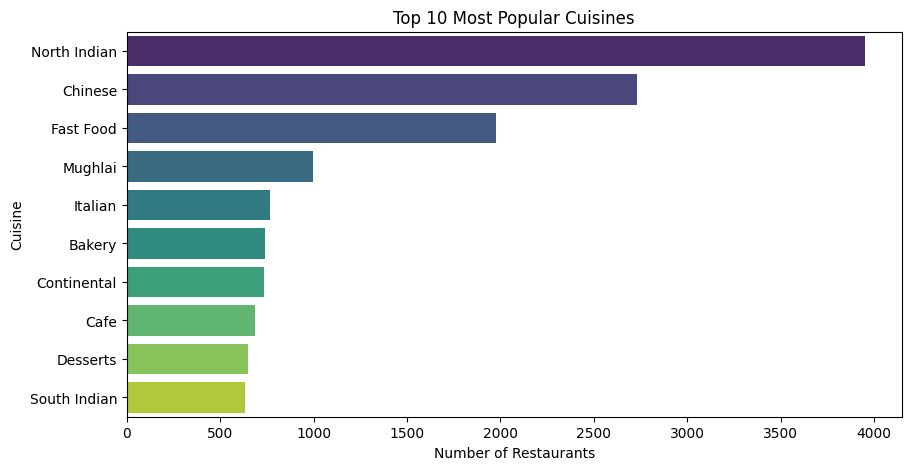

In [13]:
top_cuisines = (
    recommend_df["Cuisines"]
    .str.split(",")
    .explode()
    .str.strip()
    .value_counts()
    .head(10)
)

plt.figure(figsize=(10,5))
sns.barplot(
    x=top_cuisines.values,
    y=top_cuisines.index,
    palette="viridis"
)

plt.title("Top 10 Most Popular Cuisines")
plt.xlabel("Number of Restaurants")
plt.ylabel("Cuisine")
plt.show()

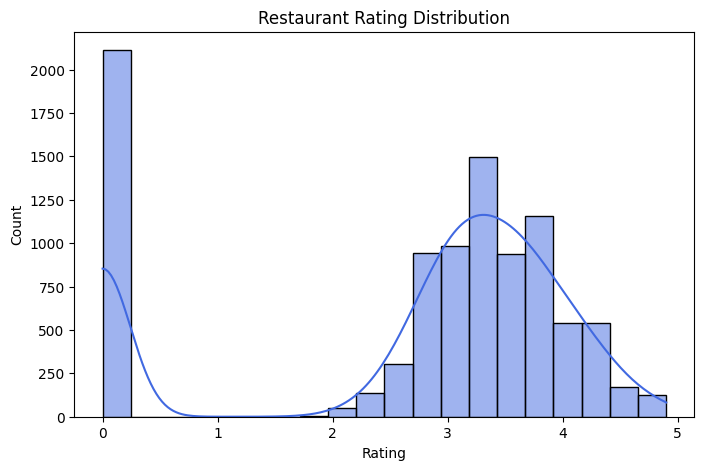

In [14]:
plt.figure(figsize=(8,5))

sns.histplot(
    recommend_df["Aggregate rating"],
    bins=20,
    kde=True,
    color="royalblue"
)

plt.title("Restaurant Rating Distribution")
plt.xlabel("Rating")
plt.ylabel("Count")

plt.show()

C:\Users\pc\AppData\Local\Temp\ipykernel_7216\3993242348.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(


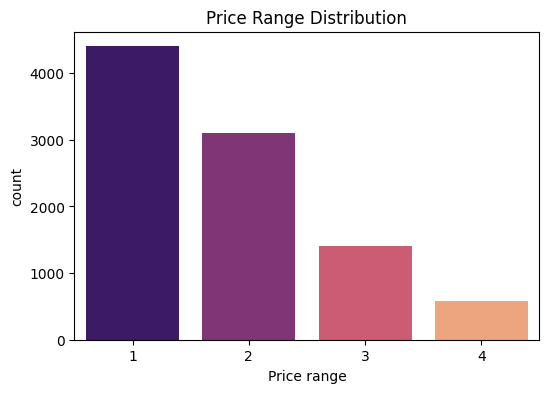

In [15]:
plt.figure(figsize=(6,4))

sns.countplot(
    x="Price range",
    data=recommend_df,
    palette="magma"
)

plt.title("Price Range Distribution")

plt.show()

# 🤖 Content-Based Recommendation System

A content-based recommendation system suggests restaurants based on the similarity of their characteristics.

In this project, the recommendation system primarily uses the **Cuisine** information of restaurants.

The following steps are performed:

- Text preprocessing
- TF-IDF Vectorization
- Cosine Similarity Calculation
- Recommendation Function

In [16]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity


In [17]:
# Fill missing cuisines (safety step)

recommend_df["Cuisines"] = recommend_df["Cuisines"].fillna("")

In [18]:
# TF-IDF Vectorization

tfidf = TfidfVectorizer(stop_words="english")

tfidf_matrix = tfidf.fit_transform(recommend_df["Cuisines"])

print("TF-IDF Matrix Shape:", tfidf_matrix.shape)

TF-IDF Matrix Shape: (9499, 148)


In [19]:
# Cosine Similarity Matrix

cosine_sim = cosine_similarity(tfidf_matrix)

print(cosine_sim.shape)

(9499, 9499)


## 📖 Observation

The TF-IDF Vectorizer converts cuisine names into numerical vectors.

Cosine Similarity measures the similarity between restaurants based on their cuisine information.

Restaurants having similar cuisines obtain higher similarity scores and are more likely to be recommended.

# 🎯 Recommendation Function

A recommendation function is created to suggest restaurants similar to a user-selected restaurant.

The recommendation is based on the cosine similarity scores computed from the TF-IDF vectors of restaurant cuisines.

The function returns the top 5 most similar restaurants along with their important details.

In [20]:
# Create restaurant index mapping

restaurant_index = pd.Series(
    recommend_df.index.values,
    index=recommend_df["Restaurant Name"]
)

restaurant_index = restaurant_index[
    ~restaurant_index.index.duplicated(keep="first")
]

In [21]:
def recommend_restaurants(restaurant_name, top_n=5):

    if restaurant_name not in restaurant_index:
        print("Restaurant not found!")
        return

    idx = int(restaurant_index[restaurant_name])

    similarity_scores = list(enumerate(cosine_sim[idx]))

    similarity_scores = sorted(
        similarity_scores,
        key=lambda x: x[1],
        reverse=True
    )

    similarity_scores = similarity_scores[1:top_n+1]

    restaurant_indices = [i[0] for i in similarity_scores]

    return recommend_df.iloc[
        restaurant_indices
    ][
        [
            "Restaurant Name",
            "City",
            "Cuisines",
            "Aggregate rating",
            "Average Cost for two",
            "Price range"
        ]
    ]

## 📖 Observation

The recommendation function identifies restaurants having cuisines similar to the selected restaurant.

Restaurants are ranked using cosine similarity scores, and the top recommendations are returned to the user.

In [22]:
recommend_restaurants("Barbeque Nation")

,Restaurant Name,City,Cuisines,Aggregate rating,Average Cost for two,Price range
578,Barbeque Nation,Dubai,"Indian, North Indian",4.5,150,3
610,Rajasthan Al Malaki,Sharjah,"Indian, North Indian",4.8,60,3
3445,Meatwale.com,New Delhi,"North Indian, Indian",0.0,300,1
617,Time2Eat - Mama Chicken,Agra,North Indian,3.6,500,2
671,Eat On,Allahabad,North Indian,3.7,200,1
